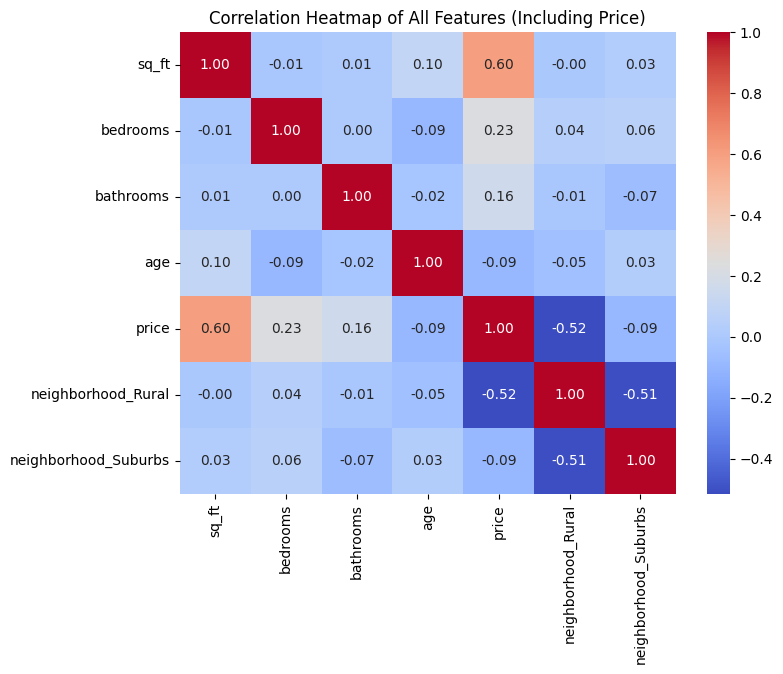

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   sq_ft                 500 non-null    float64
 1   bedrooms              500 non-null    int64  
 2   bathrooms             500 non-null    float64
 3   age                   500 non-null    int64  
 4   price                 500 non-null    int64  
 5   neighborhood_Rural    500 non-null    bool   
 6   neighborhood_Suburbs  500 non-null    bool   
dtypes: bool(2), float64(2), int64(3)
memory usage: 20.6 KB
None

             sq_ft    bedrooms  bathrooms         age          price
count   500.000000  500.000000  500.00000  500.000000     500.000000
mean   1802.115627    3.182000    2.08940    9.416000  322415.782000
std     480.132756    1.032962    0.73175    9.354676   94030.978396
min     800.000000    1.000000    1.00000    0.000000  118045.000000
25%    1452.693213    2.000000    1.5

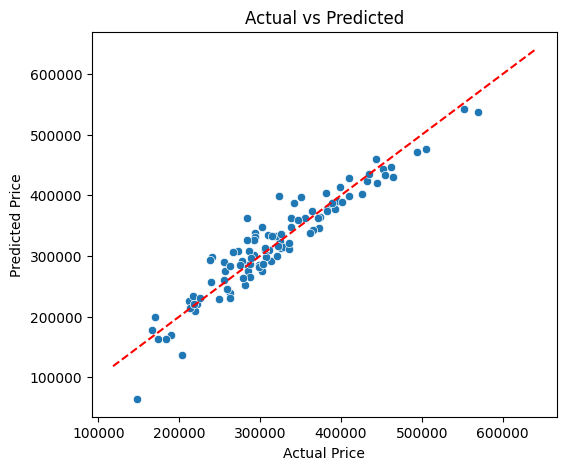

R2 Score: 0.90
RMSE: 26464.32
MAE: 20435.47

Predicted Price for new house: $272076.69


In [24]:
#1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

def generate_house_data(n_samples=500, seed=42):
    np.random.seed(seed)
    
    # Feature distributions
    sq_ft = np.random.normal(1800, 500, n_samples).clip(800, 3500)
    bedrooms = np.random.choice([1, 2, 3, 4, 5], n_samples, p=[0.05, 0.2, 0.35, 0.3, 0.1])
    bathrooms = np.round(np.random.normal(2, 0.8, n_samples).clip(1, 4), 1)
    age = np.random.exponential(10, n_samples).astype(int).clip(0, 50)
    neighborhood = np.random.choice(['Suburbs', 'Downtown', 'Rural'], n_samples, p=[0.5, 0.3, 0.2])
    
    # Price formula with plausible coefficients + noise
    base_price = (
        120 * sq_ft +
        25000 * bedrooms +
        15000 * bathrooms -
        1500 * age
    )
    # Neighborhood adjustments
    neighborhood_mult = {'Downtown': 1.3, 'Suburbs': 1.0, 'Rural': 0.7}
    price = base_price * [neighborhood_mult[n] for n in neighborhood] + np.random.normal(0, 20000, n_samples)
    price = price.clip(50000, 1000000).astype(int)
    
    # Introduce a few missing sq_ft values
    missing_mask = np.random.choice([True, False], n_samples, p=[0.02, 0.98])
    sq_ft[missing_mask] = np.nan
    
    return pd.DataFrame({
        'sq_ft': sq_ft,
        'bedrooms': bedrooms,
        'bathrooms': bathrooms,
        'age': age,
        'neighborhood': neighborhood,
        'price': price
    })

# Generate 500 samples
df = generate_house_data(500)

df['sq_ft'] = df['sq_ft'].fillna(df['sq_ft'].mean())

df = pd.get_dummies(df, columns=['neighborhood'], drop_first=True)

plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of All Features (Including Price)')
plt.show()

print(f"{df.info()}\n")
print(f"{df.describe()}\n")

X = df.drop('price', axis=1)
y = df['price']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()

model.fit(X_train_scaled, y_train)

preds = model.predict(X_test_scaled)

plt.figure(figsize=(6, 5))
sns.scatterplot(x=y_test, y=preds)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted')
plt.show()

print(f"R2 Score: {r2_score(y_test, preds):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, preds)):.2f}")
print(f"MAE: {mean_absolute_error(y_test, preds):.2f}")

# Features: sq_ft, bedrooms, bathrooms, age, Rural, Downtown
new_house = [[2200, 3, 2, 5, 1, 0]]
new_house_scaled = scaler.transform(new_house)
prediction = model.predict(new_house_scaled)
print(f"\nPredicted Price for new house: ${prediction[0]:.2f}")

Logistic Regression Accuracy: 0.7000
              precision    recall  f1-score   support

    Not Spam       0.57      1.00      0.73         8
        Spam       1.00      0.50      0.67        12

    accuracy                           0.70        20
   macro avg       0.79      0.75      0.70        20
weighted avg       0.83      0.70      0.69        20

──────────────────────────────────────────────────
Decision Tree Accuracy: 0.6500
              precision    recall  f1-score   support

    Not Spam       0.53      1.00      0.70         8
        Spam       1.00      0.42      0.59        12

    accuracy                           0.65        20
   macro avg       0.77      0.71      0.64        20
weighted avg       0.81      0.65      0.63        20



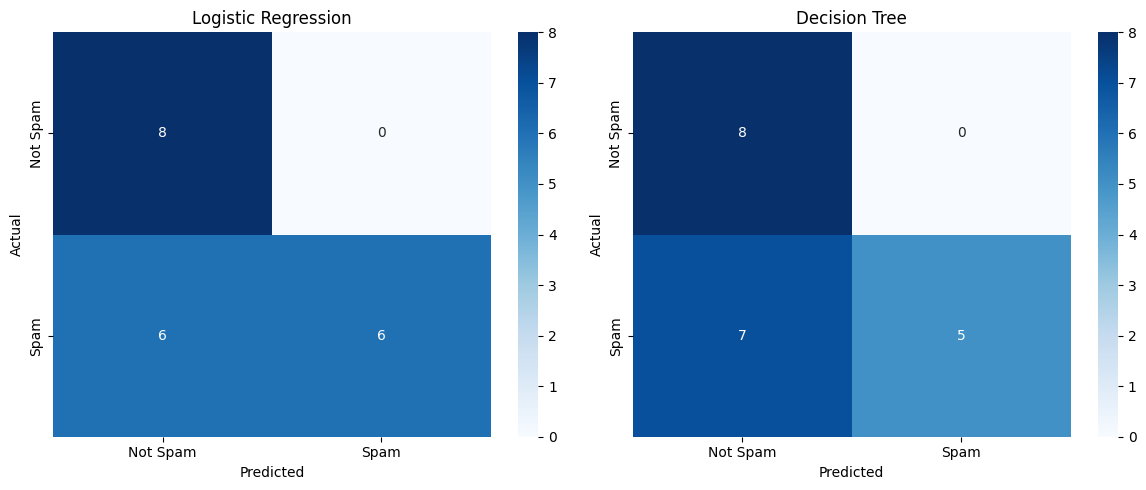

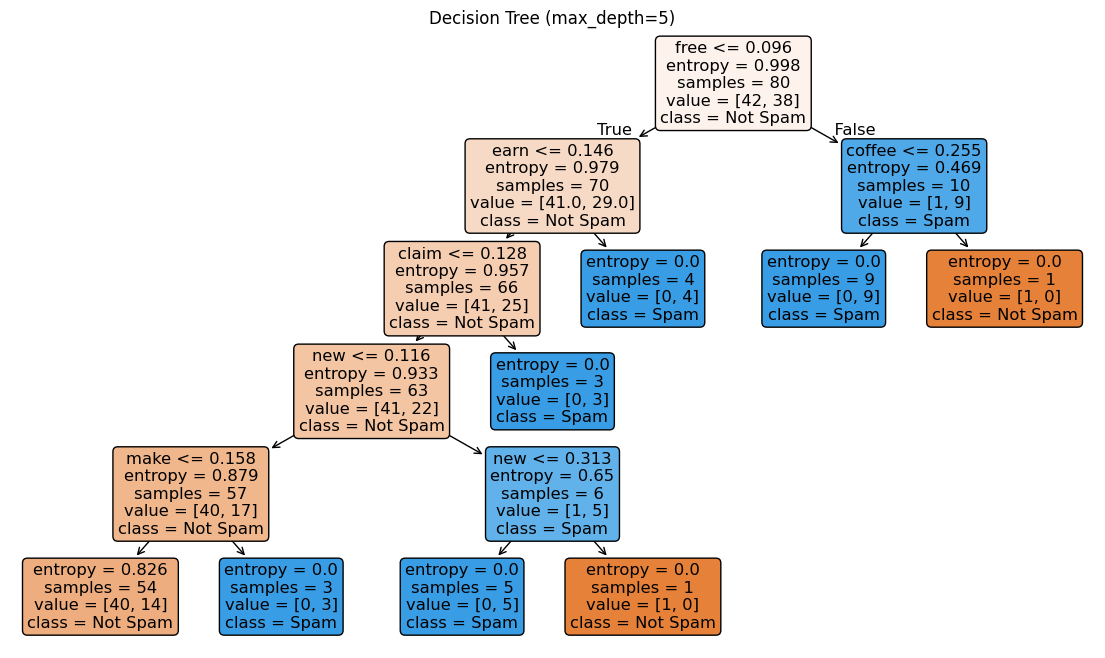


-> Best model: Logistic Regression (Accuracy: 0.7000)

Prediction on new messages:
  [SPAM] (confidence: 0.608)  →  "Win a free vacation to the Bahamas! Click here now."
  [NOT SPAM] (confidence: 0.357)  →  "Reminder: your project report is due tomorrow by 5 PM."
  [SPAM] (confidence: 0.589)  →  "You have been selected for a $500 gift card. Claim it."
  [NOT SPAM] (confidence: 0.441)  →  "Can we reschedule our meeting to Thursday?"
  [SPAM] (confidence: 0.582)  →  "Make money fast with no effort - guaranteed."


In [50]:
#2
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

data = {
    'content': [
        # --- SPAM (1) ---
        "URGENT: You have won a free iPhone 15! Claim your prize now by clicking here.",
        "Dear customer, your bank account has been limited. Please verify your identity immediately.",
        "Get rich quick! Earn $5000 per week from home with this simple method.",
        "Congratulations! You've been selected for an exclusive $1000 Amazon gift card. Redeem now.",
        "Your PayPal account has been suspended due to suspicious activity. Restore access now.",
        "Limited time offer: Buy one get one free on all designer watches. Click here.",
        "Meet singles in your area tonight! Free registration for the next 24 hours.",
        "Investment opportunity: Double your money in 3 days. Guaranteed returns!",
        "You have (1) new unread message from an unknown sender. View it now.",
        "Lose 20 pounds in 2 weeks without diet or exercise! Order your free trial.",
        "CREDIT CUP: Your card has been charged $499.99 for antivirus renewal. If unauthorized, call now.",
        "Earn cash by completing surveys online. Sign up today and get a $50 bonus.",
        "Free Disney World tickets! Just share this link with 10 friends.",
        "Your email ID has won £1,000,000 in the Euro lottery. Contact us to claim.",
        "This is your final notice: Your package could not be delivered. Confirm your address here.",
        "Work from home and make $300/day. No experience needed! Start immediately.",
        "Sexy photos inside! Check out my private gallery – free access for one day only.",
        "Download our app now and get a free $100 Walmart voucher. Limited to first 1000 users.",
        "Your iCloud storage is full. Upgrade now to avoid losing your data. Click this link.",
        "RE: Your tax refund of $2,450 is ready. Submit your details to receive payment.",
        "Join our VIP club and enjoy exclusive discounts on luxury goods. Membership free today.",
        "You have been chosen to test Apple’s new product! Apply now – limited spots.",
        "DEBT RELIEF: Consolidate all your loans into one easy payment. Call now for free quote.",
        "Don't miss out! Our stock tip of the year could make you a millionaire.",
        "Click here to claim your free Netflix account for 1 year! No credit card required.",
        "Your computer may be infected! Download our free virus removal tool now.",
        "Get cheap medications online – no prescription needed! Discreet shipping worldwide.",
        "Act now: Only 2 hours left to claim your spot in our exclusive webinar.",
        "You’ve won a brand new Samsung Galaxy S23! Finish 3 short steps to receive it.",
        "This is not a scam! We really want to give you money. Just submit your bank details.",
        "Your Facebook account has been flagged for violation. Verify immediately or be disabled.",
        "HOT DEAL: 90% off all Ray-Ban sunglasses. Official distributor clearance.",
        "Make $1000 today by simply watching YouTube videos. Find out how.",
        "Final warning: Your antivirus subscription has expired. Renew now to stay protected.",
        "Participate in our paid clinical trial and earn up to $5,000.",
        "Click this link for a chance to board the maiden voyage of a new luxury cruise.",
        "Warning: You have (3) critical security issues on your PC. Fix them now.",
        "Become a mystery shopper and get paid to shop and dine. Apply within!",
        "Fantastic news! Your Gmail account has won the Google promotion. Collect prize here.",
        "Hi dear, I am a rich prince needing to transfer funds. Help me and get 30%.",
        "Free bitcoin giveaway! Send 0.1 BTC to this address and receive 1 BTC back.",
        "Your ATM card has been blocked. To unblock, call our customer care number immediately.",
        "Heavy discounts on flight tickets this weekend only. Book now and save 60%.",
        "Congratulations! You can now claim your $500 donation from the Bill Gates Foundation.",
        "Find hot dates in your city with our new dating app. Free to join.",
        "SIGN UP NOW for our free newsletter and get insider trading tips weekly.",
        "We noticed unusual activity on your Netflix account. Confirm your email to keep access.",
        "Become an affiliate and earn 40% commission on every sale. No investment needed.",
        "It's your lucky day! Spin the wheel and win a new car. Click here to play.",
        "THIS IS AN ADVERTISEMENT: Refinance your mortgage at a record low rate. Apply online.",
        
        # --- NOT SPAM (0) ---
        "Hey, are we still meeting for lunch at 12:30 today?",
        "The draft for the quarterly report is attached for your review.",
        "Don't forget to pick up milk on your way home tonight.",
        "Meeting notes from yesterday – see attached.",
        "Can you send me the budget spreadsheet before the 3pm call?",
        "Happy birthday! Hope you have a wonderful day filled with joy.",
        "Reminder: dentist appointment tomorrow at 10am. Let me know if you need a ride.",
        "I'll be home a bit late tonight – traffic is terrible.",
        "Let's grab coffee this weekend if you’re free.",
        "The project deadline has been extended to next Friday. Please update your timeline.",
        "Just checking in, how are you feeling today?",
        "Please review the contract and return the signed copy by Monday.",
        "Are you available for a quick call at 2pm regarding the client feedback?",
        "Mom says hi and wants to know if you’re coming for dinner Sunday.",
        "The kids are asking about the camping trip – shall we plan for July?",
        "I left my charger at your place. Could you bring it tomorrow?",
        "Great job on the presentation! The clients loved it.",
        "Here's the recipe I was telling you about – enjoy!",
        "Did you see the email from HR about the new benefits package?",
        "My flight lands at 7pm, gate C12. See you then!",
        "I'm running a few minutes late for the meeting – starting without me is fine.",
        "Updated design files are in the shared folder. Please take a look.",
        "Thanks for helping me move on Saturday – you were a lifesaver.",
        "Can you pick up the kids from soccer practice at 5? I have a late meeting.",
        "Dinner was fantastic last night! We should do it again soon.",
        "The conference call details: dial 800-555-0199, passcode 1234.",
        "I've uploaded the photos from the trip to the cloud album – check them out.",
        "Your order of books has been shipped. Tracking number: 1Z999AA10123456784.",
        "Don’t forget to submit your timesheet by noon tomorrow.",
        "I'll meet you at the cinema at 7:45. I already bought tickets.",
        "Let me know if you need any references for the job application.",
        "Could you proofread my email draft before I send it to the director?",
        "I'm planning a surprise party for Alex – are you in?",
        "All hands meeting postponed to Thursday – calendar invite updated.",
        "Here's the link to the online lecture I mentioned: [edu.example.com/cs101]",
        "Your library book is due back this Friday. No rush, just a heads-up.",
        "The AC repair guy will be there between 1 and 4pm. Can you be home?",
        "Happy anniversary! Three years of putting up with me.",
        "Please RSVP to the wedding invitation by the end of the week.",
        "I've attached the final version of the thesis – let me know your thoughts.",
        "I got the job! Thanks for the interview practice – it helped a lot.",
        "Don't worry about the mistake, we can fix it together tomorrow.",
        "Are you still up for hiking on Saturday? Weather looks good.",
        "Your appointment at the salon is confirmed for Friday 11am.",
        "I found your keys under the couch. I'll leave them on the counter.",
        "Can you water my plants while I'm away? They're in the kitchen.",
        "Happy Ramadan! Wishing you and your family light and happiness.",
        "The team lunch is still on. We'll meet at the lobby at 12:15.",
        "Please update your emergency contact info in the portal.",
        "Just saw the movie you recommended – absolutely loved it!"
    ],
    'is_spam': [1]*50 + [0]*50
}

df = pd.DataFrame(data)

# Preprocessing
vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(df['content'])
y = df['is_spam']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modeling
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

dt_model = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42) # Information Gain
dt_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)
y_pred_dt = dt_model.predict(X_test)

acc_lr = accuracy_score(y_test, y_pred_lr)
acc_dt = accuracy_score(y_test, y_pred_dt)

print(f"Logistic Regression Accuracy: {acc_lr:.4f}")
print(classification_report(y_test, y_pred_lr, target_names=['Not Spam', 'Spam']))
print("─" * 50)
print(f"Decision Tree Accuracy: {acc_dt:.4f}")
print(classification_report(y_test, y_pred_dt, target_names=['Not Spam', 'Spam']))

# confusion Matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Spam', 'Spam'], yticklabels=['Not Spam', 'Spam'], ax=axes[0])
axes[0].set_title('Logistic Regression')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Spam', 'Spam'], yticklabels=['Not Spam', 'Spam'], ax=axes[1])
axes[1].set_title('Decision Tree')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 8))
plot_tree(dt_model, feature_names=vectorizer.get_feature_names_out(),
          class_names=['Not Spam', 'Spam'], filled=True, rounded=True)
plt.title("Decision Tree (max_depth=5)")
plt.show()

if acc_lr >= acc_dt:
    best_model = lr_model
    best_name = "Logistic Regression"
else:
    best_model = dt_model
    best_name = "Decision Tree"

print(f"\n-> Best model: {best_name} (Accuracy: {max(acc_lr, acc_dt):.4f})")

new_messages = [
    "Win a free vacation to the Bahamas! Click here now.",
    "Reminder: your project report is due tomorrow by 5 PM.",
    "You have been selected for a $500 gift card. Claim it.",
    "Can we reschedule our meeting to Thursday?",
    "Make money fast with no effort - guaranteed."
]

X_new = vectorizer.transform(new_messages)
predictions = best_model.predict(X_new)
probs = best_model.predict_proba(X_new)[:, 1]   # probability of being spam

print("\nPrediction on new messages:")
for msg, pred, prob in zip(new_messages, predictions, probs):
    label = "SPAM" if pred == 1 else "NOT SPAM"
    print(f"  [{label}] (confidence: {prob:.3f})  →  \"{msg}\"")

--- SVM (Hyperplane) Evaluation ---
              precision    recall  f1-score   support

           0       0.94      0.73      0.82        22
           1       0.74      0.94      0.83        18

    accuracy                           0.82        40
   macro avg       0.84      0.84      0.82        40
weighted avg       0.85      0.82      0.82        40


--- Decision Tree Evaluation ---
              precision    recall  f1-score   support

           0       0.94      0.68      0.79        22
           1       0.71      0.94      0.81        18

    accuracy                           0.80        40
   macro avg       0.82      0.81      0.80        40
weighted avg       0.83      0.80      0.80        40



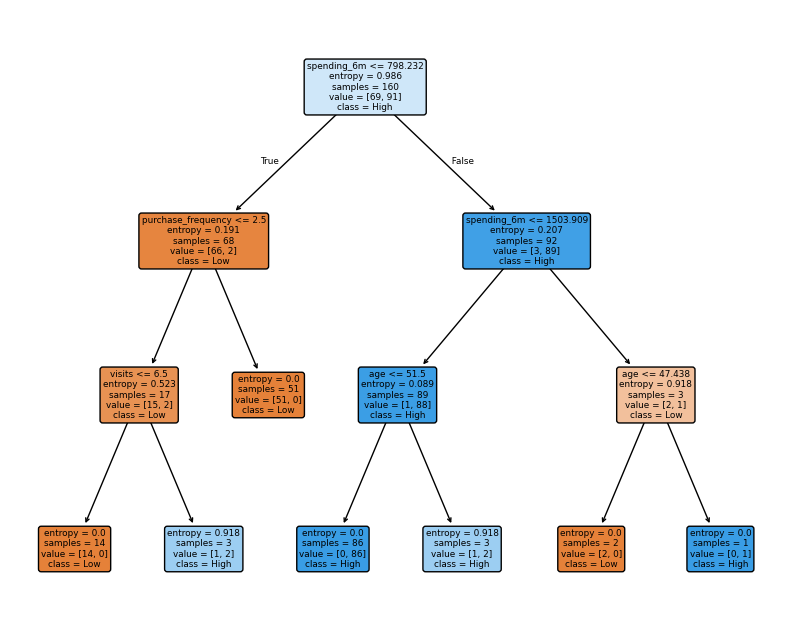

In [63]:
#3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix

# 1. Dataset Creation & Cleaning
np.random.seed(42)
n = 200

# Generate base features
age = np.random.normal(35, 10, n).astype(int)
visits = np.random.poisson(lam=8, size=n)
spending_6m = 200 + visits * 80 + np.random.normal(0, 150, n)
spending_6m = np.maximum(spending_6m, 10)   # no negative spending
purchase_frequency = np.random.poisson(lam=visits/2 + 1, size=n).astype(float)

# Create target: high-value if spending > 800 or (visits > 15 and spending > 500)
is_high_value = ((spending_6m > 800) | ((visits > 15) & (spending_6m > 500))).astype(int)

# Introduce some randomness to make the problem realistic
flip_idx = np.random.choice(n, size=int(0.05*n), replace=False)
is_high_value[flip_idx] = 1 - is_high_value[flip_idx]

# Introduce missing values (NaN) in about 5% of entries
for col in ['spending_6m', 'age', 'visits', 'purchase_frequency']:
    nan_idx = np.random.choice(n, size=int(0.05*n), replace=False)
    df_col = locals()[col].astype(float)  # convert to float to hold NaN
    df_col[nan_idx] = np.nan
    locals()[col] = df_col

# Add some extreme outliers (will be clipped later)
spending_6m[10] = 5000   # extreme spender
visits[20] = 50          # extreme visits
age[30] = 5              # unrealistic age (should be clipped)

# Build the DataFrame
data = pd.DataFrame({
    'spending_6m': spending_6m,
    'age': age,
    'visits': visits,
    'purchase_frequency': purchase_frequency,
    'is_high_value': is_high_value
})

df = data.copy()

# Handle Missing/Outliers: Using median for robustness
df.fillna(df.median(), inplace=True)

for col in ['spending_6m', 'age', 'visits', 'purchase_frequency']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower, upper)

# 2. Feature Scaling (Syllabus Requirement: Scaling)
X = df.drop('is_high_value', axis=1)
y = df['is_high_value']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
X_train_u, X_test_u = train_test_split(X, test_size=0.2, random_state=42)[:2]  # match indices

# SVM Hyperplane
svm_model = SVC(kernel='linear')
svm_model.fit(X_train, y_train)

# Find Classification Rules (Decision Tree)
dt_model = DecisionTreeClassifier(criterion='entropy', max_depth=3)
dt_model.fit(X_train_u, y_train)

# 6. Evaluation
print("--- SVM (Hyperplane) Evaluation ---")
print(classification_report(y_test, svm_model.predict(X_test)))

print("\n--- Decision Tree Evaluation ---")
print(classification_report(y_test, dt_model.predict(X_test_u)))

plt.figure(figsize=(10,8))
plot_tree(dt_model, feature_names=X.columns, class_names=['Low', 'High'], filled=True, rounded=True)
plt.show()